# Lab 08: Statistics & Random Sampling

## Examples (by instructor)

In this lab, you'll apply the statistics tools from Chapter 13 to real engineering data: summarizing datasets with descriptive statistics, working with probability distributions (uniform and normal), computing probabilities using the CDF and PPF, and building confidence intervals for the mean.

### Example 1: Descriptive Statistics — `np.mean`, `np.std`, `np.percentile`

A heat exchanger is monitored over 20 operating days. The overall heat transfer coefficient $U$ (W/m²·K) was recorded each day:

```
412, 398, 425, 431, 407, 389, 418, 444, 402, 415,
421, 396, 438, 410, 426, 393, 442, 408, 419, 435
```

The design specification requires $U \geq 395$ W/m²·K. Compute:
1. Mean, median, standard deviation (sample), and IQR
2. What fraction of days fall below the spec limit?
3. The 5th and 95th percentiles

Descriptive statistics for heat transfer coefficient U
--------------------------------------------------
  N                 : 20
  Mean              : 416.45 W/m²·K
  Median            : 416.50 W/m²·K
  Std dev (sample)  : 16.42 W/m²·K
  IQR               : 21.50 W/m²·K  (Q1=405.8, Q3=427.2)

  Days below 395.0 W/m²·K : 2 / 20  (10.0%)

  5th  percentile   : 392.80 W/m²·K
  95th percentile   : 442.10 W/m²·K


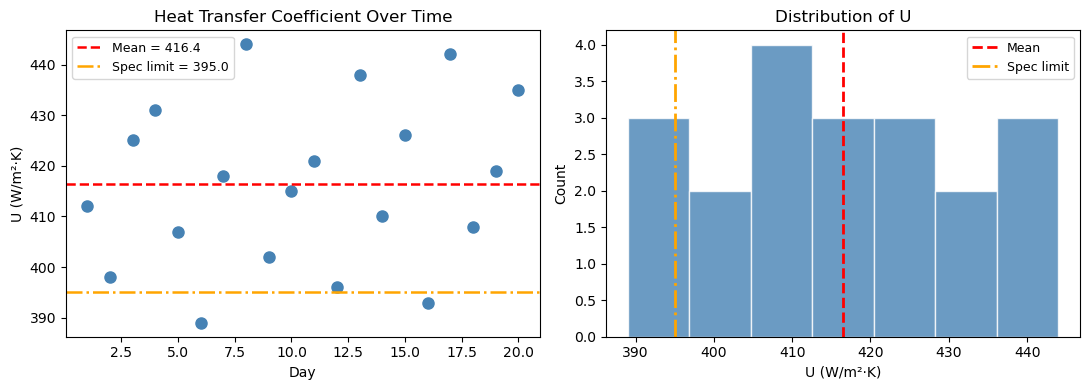

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

U = np.array([412, 398, 425, 431, 407, 389, 418, 444, 402, 415,
              421, 396, 438, 410, 426, 393, 442, 408, 419, 435], dtype=float)

spec_limit = 395.0

# ── 1. Descriptive statistics ─────────────────────────────────────────────────
print("Descriptive statistics for heat transfer coefficient U")
print("-" * 50)
print(f"  N                 : {len(U)}")
print(f"  Mean              : {np.mean(U):.2f} W/m²·K")
print(f"  Median            : {np.median(U):.2f} W/m²·K")
print(f"  Std dev (sample)  : {np.std(U, ddof=1):.2f} W/m²·K")
q1 = np.percentile(U, 25)
q3 = np.percentile(U, 75)
print(f"  IQR               : {q3 - q1:.2f} W/m²·K  (Q1={q1:.1f}, Q3={q3:.1f})")

# ── 2. Fraction below spec ────────────────────────────────────────────────────
n_fail = np.sum(U < spec_limit)
print(f"\n  Days below {spec_limit} W/m²·K : {n_fail} / {len(U)}  ({100*n_fail/len(U):.1f}%)")

# ── 3. Percentiles ────────────────────────────────────────────────────────────
p5  = np.percentile(U, 5)
p95 = np.percentile(U, 95)
print(f"\n  5th  percentile   : {p5:.2f} W/m²·K")
print(f"  95th percentile   : {p95:.2f} W/m²·K")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(range(1, len(U)+1), U, 'o', color='steelblue', markersize=8)
ax.axhline(np.mean(U),  color='red',    linestyle='--', linewidth=1.8,
           label=f'Mean = {np.mean(U):.1f}')
ax.axhline(spec_limit,  color='orange', linestyle='-.', linewidth=1.8,
           label=f'Spec limit = {spec_limit}')
ax.set_xlabel('Day'); ax.set_ylabel('U (W/m²·K)')
ax.set_title('Heat Transfer Coefficient Over Time'); ax.legend(fontsize=9)

ax = axes[1]
ax.hist(U, bins=7, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(np.mean(U), color='red',    linestyle='--', linewidth=2, label='Mean')
ax.axvline(spec_limit, color='orange', linestyle='-.', linewidth=2, label='Spec limit')
ax.set_xlabel('U (W/m²·K)'); ax.set_ylabel('Count')
ax.set_title('Distribution of U'); ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### Example 2: Normal Distribution — CDF and PPF

A distillation column produces a product stream with purity that follows a **Normal distribution** with mean $\mu = 97.5\%$ and standard deviation $\sigma = 0.8\%$.

The product specification requires purity $\geq 96.0\%$.

Use `scipy.stats.norm` to answer:
1. What fraction of batches **fail** the spec (purity < 96%)?
2. What is the purity value at the **1st percentile** (i.e., only 1% of batches are worse)?
3. Plot the PDF and shade the failing region

In [ ]:
mu_purity    = 97.5    # % — mean purity
sigma_purity = 0.8     # % — standard deviation
spec_min     = 96.0    # % — minimum acceptable purity

dist_purity = stats.norm(loc=mu_purity, scale=sigma_purity)

# ── 1. Fraction of batches failing the spec ───────────────────────────────────
p_fail = dist_purity.cdf(spec_min)
print(f"P(purity < {spec_min}%) = {p_fail:.4f}  →  {100*p_fail:.2f}% of batches fail")

# ── 2. 1st percentile (worst 1% threshold) ───────────────────────────────────
p1 = dist_purity.ppf(0.01)
print(f"1st percentile purity   = {p1:.2f}%  (1% of batches are worse than this)")

# ── 3. PDF plot with failing region shaded ────────────────────────────────────
x = np.linspace(mu_purity - 4*sigma_purity, mu_purity + 4*sigma_purity, 400)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, dist_purity.pdf(x), 'steelblue', linewidth=2.5,
        label=r'$\mathcal{N}(97.5,\; 0.8^2)$')

# Shade failing region (purity < spec_min)
x_fail = np.linspace(x[0], spec_min, 200)
ax.fill_between(x_fail, dist_purity.pdf(x_fail), color='tomato', alpha=0.5,
                label=f'Fail region  ({100*p_fail:.2f}%)')

ax.axvline(spec_min, color='red', linestyle='--', linewidth=1.5,
           label=f'Spec limit = {spec_min}%')
ax.axvline(mu_purity, color='gray', linestyle=':', linewidth=1.5,
           label=f'Mean = {mu_purity}%')
ax.set_xlabel('Purity (%)', fontsize=12)
ax.set_ylabel('f(x)', fontsize=12)
ax.set_title('Product Purity: Normal Distribution', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Example 3: Confidence Interval for the Mean

A process engineer collects **12 measurements** of outlet temperature (°C) from a reactor:

```
312.4, 309.8, 315.1, 311.7, 308.9, 313.5,
316.2, 310.3, 314.0, 312.8, 309.1, 315.7
```

Compute the **90%, 95%, and 99% confidence intervals** for the true mean outlet temperature using the $t$-distribution. Then show how the CI width changes as sample size grows.

In [ ]:
T_outlet = np.array([312.4, 309.8, 315.1, 311.7, 308.9, 313.5,
                     316.2, 310.3, 314.0, 312.8, 309.1, 315.7])

n    = len(T_outlet)
xbar = np.mean(T_outlet)
s    = np.std(T_outlet, ddof=1)
se   = s / np.sqrt(n)

print(f"n = {n},  mean = {xbar:.2f} °C,  s = {s:.2f} °C,  SE = {se:.2f} °C")
print()

for conf in [0.90, 0.95, 0.99]:
    lo, hi = stats.t.interval(conf, df=n-1, loc=xbar, scale=se)
    t_crit = stats.t.ppf(1 - (1-conf)/2, df=n-1)
    print(f"  {int(100*conf)}% CI:  [{lo:.2f}, {hi:.2f}] °C   (t_crit={t_crit:.3f}, width={hi-lo:.2f} °C)")

---

## Warm-Up: Syntax Practice

Short exercises to get comfortable with the key statistics functions before the main problems.

**Exercise 1 — Descriptive statistics.**

Given the following 8 reactor conversion measurements (%), compute the mean, median, sample standard deviation, and IQR. Then print whether the mean and median are close (within 1%).

```
78.2, 81.5, 76.9, 83.1, 79.4, 80.7, 77.8, 82.3
```

In [ ]:
import numpy as np

X = np.array([78.2, 81.5, 76.9, 83.1, 79.4, 80.7, 77.8, 82.3])

mean   = ___                          # mean
median = ___                          # median
std    = ___                          # sample std dev (ddof=1)
iqr    = ___ - ___                    # Q3 - Q1 (use np.percentile)

print(f"Mean   = {mean:.2f} %")
print(f"Median = {median:.2f} %")
print(f"Std    = {std:.2f} %")
print(f"IQR    = {iqr:.2f} %")

if abs(mean - median) < 1.0:
    print("Mean and median are close — distribution is roughly symmetric.")
else:
    print("Mean and median differ — distribution may be skewed.")

**Exercise 2 — Random sampling with a seed.**

Generate 1000 samples from a **Normal distribution** with mean 350 K and standard deviation 15 K using `np.random.default_rng(seed=7)`. Then:

1. Print the sample mean and sample standard deviation
2. Print what fraction of samples exceed 375 K

In [ ]:
import numpy as np

rng = np.random.default_rng(seed=___)   # use seed=7

samples = rng.normal(___, ___, ___)     # loc=350, scale=15, size=1000

print(f"Sample mean : {np.mean(samples):.2f} K")
print(f"Sample std  : {np.std(samples, ddof=1):.2f} K")

frac_above = ___                        # fraction of samples > 375
print(f"Fraction > 375 K : {frac_above:.4f}")

**Exercise 3 — CDF and PPF.**

Flow rate through a valve follows a **Normal distribution** $\mathcal{N}(\mu=50,\, \sigma=4)$ L/min.

Use `scipy.stats.norm` to answer:
1. What fraction of the time is flow rate below 45 L/min? (`cdf`)
2. What flow rate is exceeded 90% of the time? (`ppf`)

In [ ]:
from scipy import stats

dist_flow = stats.norm(loc=___, scale=___)   # mu=50, sigma=4

# 1. P(flow < 45)
p_below_45 = ___                             # use .cdf()
print(f"P(flow < 45 L/min) = {p_below_45:.4f}")

# 2. Flow rate exceeded 90% of the time  →  10th percentile
flow_p10 = ___                               # use .ppf(0.10)
print(f"Flow exceeded 90% of the time = {flow_p10:.2f} L/min")

**Exercise 4 — Confidence interval.**

Six repeat measurements of a feed concentration (mol/L) are:

```
1.82, 1.79, 1.85, 1.77, 1.83, 1.80
```

Compute the **95% confidence interval** for the true mean concentration using `scipy.stats.t.interval`. Print the interval and its width.

In [ ]:
import numpy as np
from scipy import stats

C_data = np.array([1.82, 1.79, 1.85, 1.77, 1.83, 1.80])

n    = len(C_data)
xbar = ___                               # sample mean
s    = ___                               # sample std (ddof=1)
se   = ___ / np.sqrt(___)               # standard error

lo, hi = stats.t.interval(___, df=___, loc=___, scale=___)   # 95% CI

print(f"Mean = {xbar:.4f} mol/L,  s = {s:.4f},  SE = {se:.4f}")
print(f"95% CI: [{lo:.4f}, {hi:.4f}] mol/L")
print(f"Width  = {hi - lo:.4f} mol/L")

---

## Practice Problems (by students)

### Problem 1: Pressure Relief Valve — Distribution Analysis

A safety engineer tests 25 pressure relief valves. The opening pressure (bar) for each valve is recorded:

| # | Pressure (bar) |
|---|---------------|
| 1–5 | 10.2, 9.8, 10.5, 10.1, 9.6 |
| 6–10 | 10.4, 9.9, 10.3, 10.7, 9.7 |
| 11–15 | 10.0, 10.6, 9.5, 10.2, 10.4 |
| 16–20 | 10.8, 9.9, 10.1, 10.3, 9.8 |
| 21–25 | 10.5, 10.0, 9.7, 10.6, 10.2 |

Valves are **rejected** if the opening pressure falls outside [9.8, 10.6] bar.

**(a)** Compute mean, median, std (sample), min, max, and IQR. Print all values.

**(b)** How many valves are rejected? What is the rejection rate (%)? Print the values of the rejected valves.

**(c)** Assume the opening pressure follows a Normal distribution with the sample mean and std you computed. Using `scipy.stats.norm`, compute the **theoretical** probability that a valve falls outside [9.8, 10.6] bar. Compare to the observed rejection rate.

**(d)** Plot a histogram of the data with:
- A vertical line at the mean
- Vertical dashed lines at the spec limits (9.8 and 10.6 bar)
- The rejected valves highlighted in red

### Problem 2: Central Limit Theorem — Reaction Yield Sampling

A batch reactor has a **true** yield distribution that is **right-skewed** (not normal). Model it as an Exponential distribution shifted to have mean 82% and minimum 60%:

$$Y = 60 + \text{Exponential}(\text{scale}=22)$$

This represents a process where most batches cluster near the lower end but occasionally produce very high yields.

**(a)** Draw 10,000 individual batch yields using `np.random.default_rng(seed=42)`. Plot their histogram. Compute and print the theoretical mean and std, and compare to the sample mean and std.

**(b)** Demonstrate the **Central Limit Theorem**: for sample sizes $n = 1, 5, 15, 50$, draw 5,000 samples of size $n$, compute each sample mean, and plot the distribution of sample means. Overlay the theoretical Normal curve $\mathcal{N}(\mu,\, \sigma^2/n)$ on each histogram.

**(c)** Fill in the table below and print it:

| $n$ | Theoretical SE = $\sigma/\sqrt{n}$ | Observed SE (std of sample means) |
|-----|-------------------------------------|-----------------------------------|
| 1   | | |
| 5   | | |
| 15  | | |
| 50  | | |

What pattern do you observe? How many times more data would you need to halve the standard error?